# Behavioral Counting Analysis


1. **Setup**  
   - Define data paths (`sourcedata_dir`), subject IDs, task names (`covert`/`overt`), and run lists.

2. **Data Loading & Parsing**  
   - For each subject × task × run:  
     - Load all LSL streams from the `.xdf` file.  
     - Select the `KeyboardMarkerStream` and convert its time-series to NumPy arrays.  
     - Identify trials by `start_trial`/`stop_trial` markers and extract each trial’s event codes and values.

3. **Accuracy Computation**  
   - **Strict**: reported count exactly equals presented count.  
   - **Lenient**: reported count is within ±1 of presented.  
   - Record a Boolean correctness list per trial.

4. **Aggregation**  
   - Compute mean and SD of strict/lenient accuracy across trials, for each subject and task.  
   - Store results in a `metrics` dictionary.

5. **Saving**  
   - Bundle all metrics (and `subjects` array) into a compressed NPZ file for downstream use.

6. **Visualization**  
   - Generate barplots showing strict vs. lenient accuracy for covert and overt tasks, one bar per subject.  
   - Add dashed horizontal lines to mark each condition’s overall mean.


In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
@author: RV
"""
import os
import numpy as np
from mnelab.io.xdf import read_raw_xdf as read_raw
import pyxdf
from os.path import join
import warnings
import mne
warnings.filterwarnings("ignore")
# Set MNE log level
mne.set_log_level('warning')

def ensure_dir(directory):
    if not os.path.exists(directory):
        os.makedirs(directory)
# Define directories

wd = r'C:\Users\Radovan\OneDrive\Radboud\Studentships\Jordy Thielen\root'
os.chdir(wd)
data_dir = join(wd, "data")
ensure_dir(data_dir)
experiment_dir = join(wd, "data", "experiment")
sourcedata_dir = join(experiment_dir, 'sourcedata')

In [2]:
import os
import numpy as np
import pyxdf
import matplotlib.pyplot as plt


# Set-up

sourcedata_dir = join(experiment_dir, 'sourcedata')
subjects    = ["VPpdia", "VPpdib", "VPpdic", "VPpdid", "VPpdie", "VPpdif", "VPpdig", "VPpdih", "VPpdii", "VPpdij",
                "VPpdik", "VPpdil", "VPpdim", "VPpdin", "VPpdio", "VPpdip", "VPpdiq", "VPpdir", "VPpdis", "VPpdit",
                "VPpdiu", "VPpdiv", "VPpdiw", "VPpdix", "VPpdiy", "VPpdiz", "VPpdiza", "VPpdizb", "VPpdizc"]
tasks_list  = ['covert', 'overt']   
runs        = {"overt": ["001"], "covert": ["001", "002", "003", "004"]}

# 2. Prepare containers to log data

metrics = {
    'covert_strict':   [], 'covert_strict_sd':   [],
    'overt_strict':    [], 'overt_strict_sd':    [],
    'covert_mae':      [], 'covert_mae_sd':      [],
    'overt_mae':       [], 'overt_mae_sd':       []
}
# Main Loop
for subject in subjects:
    for task in tasks_list:
        strict_list = []
        mae_list    = []

        for run in runs[task]:
            # Load all LSL streams from the .xdf file
            fn = os.path.join(
                sourcedata_dir,
                f"sub-{subject}", "ses-S001", "eeg",
                f"sub-{subject}_ses-S001_task-{task}_run-{run}_eeg.xdf"
            )
            streams, _ = pyxdf.load_xdf(fn, dejitter_timestamps=True)

            # Extract the KeyboardMarkerStream
            marker = next(
                s for s in streams
                if s['info']['name'][0] == "KeyboardMarkerStream"
            )
            data  = np.asarray(marker['time_series'])
            codes = data[:, 2]           # event codes 
            vals  = data[:, 3].astype(str)  # corresponding values

            # Find trial boundaries
            starts = np.where(codes == "start_trial")[0]
            ends   = np.where(codes == "stop_trial")[0]

            # Process each trial
            for s_idx, e_idx in zip(starts, ends):
                tcodes = codes[s_idx:e_idx+1]
                tvals  = vals[s_idx:e_idx+1]

                # Determine cued side and number of targets
                cued = tvals[np.where(tcodes == "cued_side")[0][0]]
                cued = cued.strip('"').lower()
                key = f"{cued}_num_targets"
                n_pres = int(float(tvals[np.where(tcodes == key)[0][0]]))

                # Extract the subject's response
                resp_idx = np.where(tcodes == "stop_response")[0]
                if resp_idx.size:
                    rep = tvals[resp_idx[0]].strip('"')
                    try:
                        reported = int(rep)
                    except ValueError:
                        reported = None
                else:
                    reported = None

                # Compute strict accuracy and absolute error
                strict_list.append(reported == n_pres)
                mae_list.append(np.nan if reported is None else abs(reported - n_pres))

        # 4. Aggregate subject statistics per task

        arr_s = np.array(strict_list, dtype=float)
        arr_e = np.array(mae_list,    dtype=float)

        metrics[f'{task}_strict'    ].append(arr_s.mean())
        metrics[f'{task}_strict_sd' ].append(arr_s.std(ddof=0))
        metrics[f'{task}_mae'       ].append(np.nanmean(arr_e))
        metrics[f'{task}_mae_sd'    ].append(np.nanstd(arr_e, ddof=0))


manuscript_dir = r'C:\Users\Radovan\OneDrive\Radboud\Studentships\Jordy Thielen\Manuscript\data'
behavioral_dir = join(manuscript_dir, 'behavioral')
ensure_dir(behavioral_dir)
out_fname = join(behavioral_dir, 'behavioral_counting.npz')

# convert lists in metrics to numpy arrays and include subjects
save_dict = {
    'subjects': np.array(subjects)
}
for key, vals in metrics.items():
    save_dict[key] = np.array(vals)

# save compressed .npz
np.savez_compressed(out_fname, **save_dict)

Stream 3: Calculated effective sampling rate 725.7609 Hz is different from specified rate 1000.0000 Hz.
Stream 2: Calculated effective sampling rate 725.5968 Hz is different from specified rate 1000.0000 Hz.
Stream 3: Calculated effective sampling rate 725.7496 Hz is different from specified rate 1000.0000 Hz.
Stream 2: Calculated effective sampling rate 727.0904 Hz is different from specified rate 1000.0000 Hz.
Stream 3: Calculated effective sampling rate 721.9789 Hz is different from specified rate 1000.0000 Hz.
Stream 1: Calculated effective sampling rate 728.9164 Hz is different from specified rate 1000.0000 Hz.
Stream 1: Calculated effective sampling rate 736.8298 Hz is different from specified rate 1000.0000 Hz.
Stream 1: Calculated effective sampling rate 733.6107 Hz is different from specified rate 1000.0000 Hz.
Stream 3: Calculated effective sampling rate 731.3433 Hz is different from specified rate 1000.0000 Hz.
Stream 2: Calculated effective sampling rate 731.9321 Hz is diff

KeyboardInterrupt: 

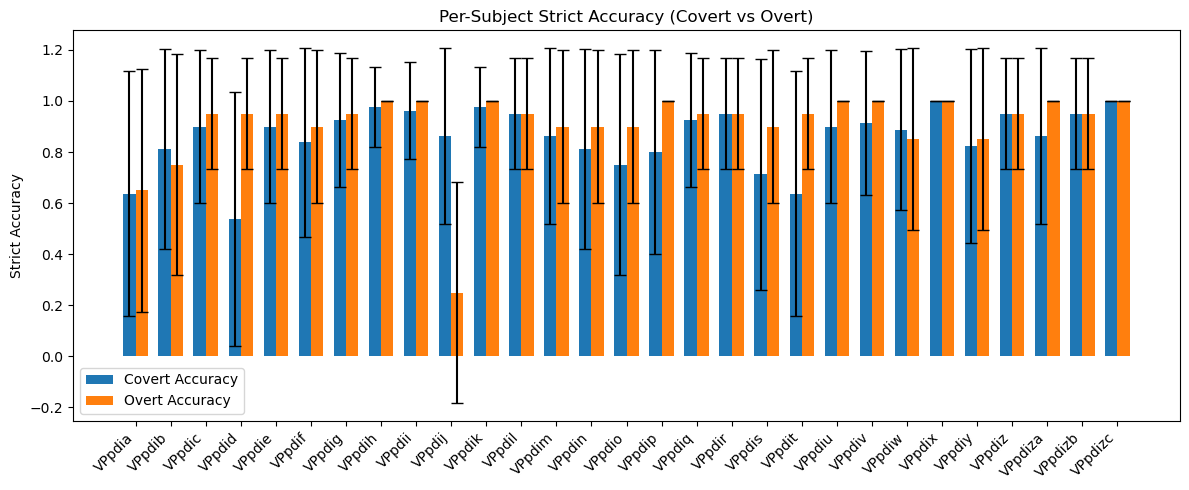

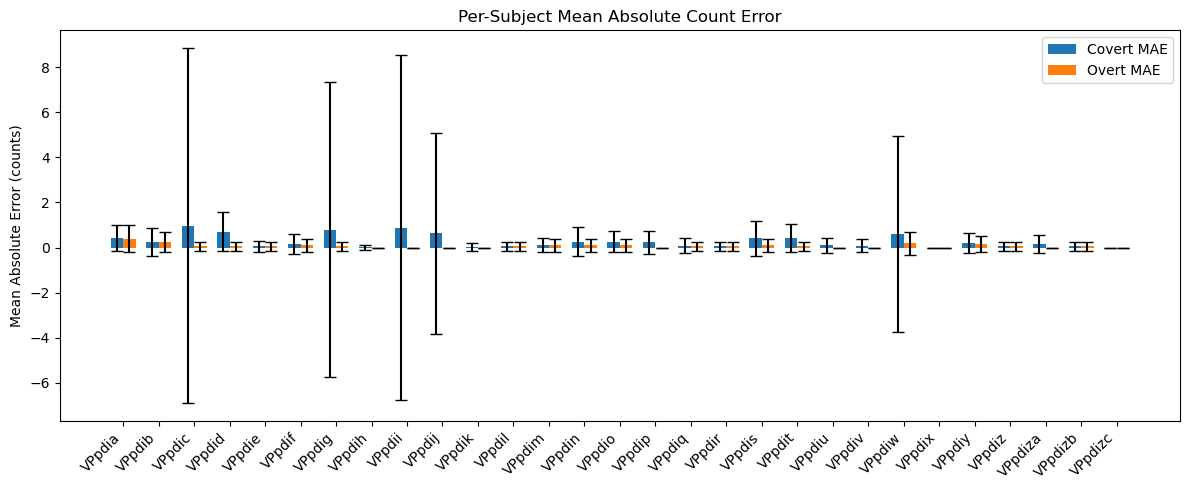

Overall Behavioral Metrics:
Covert Accuracy: 86.2% ± 11.3%
Overt Accuracy : 90.9% ± 14.7%
Covert MAE     : 0.28 ± 0.28 counts
Overt MAE      : 0.07 ± 0.09 counts


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os


behavioral_path = r'C:\Users\Radovan\OneDrive\Radboud\Studentships\Jordy Thielen\Manuscript\data\behavioral\behavioral_counting.npz'
data = np.load(behavioral_path)

subjects = data['subjects']
n = len(subjects)
x = np.arange(n)
width = 0.35

# Extract
covert_acc    = data['covert_strict']
covert_acc_sd = data['covert_strict_sd']
overt_acc     = data['overt_strict']
overt_acc_sd  = data['overt_strict_sd']

covert_mae    = data['covert_mae']
covert_mae_sd = data['covert_mae_sd']
overt_mae     = data['overt_mae']
overt_mae_sd  = data['overt_mae_sd']

# — Plot Strict Accuracy —
plt.figure(figsize=(12,5))
plt.bar(x - width/2, covert_acc,    width, yerr=covert_acc_sd, capsize=4, label='Covert Accuracy')
plt.bar(x + width/2, overt_acc,     width, yerr=overt_acc_sd,  capsize=4, label='Overt Accuracy')
plt.xticks(x, subjects, rotation=45, ha='right')
plt.ylabel('Strict Accuracy')
plt.title('Per-Subject Strict Accuracy (Covert vs Overt)')
plt.legend()
plt.tight_layout()
plt.show()

# — Plot Mean Absolute Error —
plt.figure(figsize=(12,5))
plt.bar(x - width/2, covert_mae,    width, yerr=covert_mae_sd, capsize=4, label='Covert MAE')
plt.bar(x + width/2, overt_mae,     width, yerr=overt_mae_sd,  capsize=4, label='Overt MAE')
plt.xticks(x, subjects, rotation=45, ha='right')
plt.ylabel('Mean Absolute Error (counts)')
plt.title('Per-Subject Mean Absolute Count Error')
plt.legend()
plt.tight_layout()
plt.show()

# — Print Overall Means ± SD —
print("Overall Behavioral Metrics:")
for name, vals, sds, unit in [
    ("Covert Accuracy", covert_acc, covert_acc_sd, "%"),
    ("Overt Accuracy",  overt_acc,  overt_acc_sd,  "%"),
    ("Covert MAE",      covert_mae, covert_mae_sd, "counts"),
    ("Overt MAE",       overt_mae,  overt_mae_sd,  "counts"),
]:
    mean = np.nanmean(vals)
    sd   = np.nanstd(vals, ddof=0)
    if unit == "%":
        print(f"{name:15s}: {mean*100:.1f}% ± {sd*100:.1f}%")
    else:
        print(f"{name:15s}: {mean:.2f} ± {sd:.2f} {unit}")
